In [157]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pytz
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import ttest_ind

In [213]:
df_raw = pd.read_csv('../data/raw/BC_A&A_with_ATD.csv')

In [214]:
df = df_raw.copy()

In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 15 columns):
 #   Column                             Non-Null Count    Dtype  
---  ------                             --------------    -----  
 0   region                             1000000 non-null  object 
 1   territory                          1000000 non-null  object 
 2   country_name                       1000000 non-null  object 
 3   workflow_uuid                      1000000 non-null  object 
 4   driver_uuid                        1000000 non-null  object 
 5   delivery_trip_uuid                 1000000 non-null  object 
 6   courier_flow                       1000000 non-null  object 
 7   restaurant_offered_timestamp_utc   1000000 non-null  object 
 8   order_final_state_timestamp_local  1000000 non-null  object 
 9   eater_request_timestamp_local      1000000 non-null  object 
 10  geo_archetype                      1000000 non-null  object 
 11  merchant_surface         

In [216]:
cols = df.columns
print(cols)

Index(['region', 'territory', 'country_name', 'workflow_uuid', 'driver_uuid',
       'delivery_trip_uuid', 'courier_flow',
       'restaurant_offered_timestamp_utc', 'order_final_state_timestamp_local',
       'eater_request_timestamp_local', 'geo_archetype', 'merchant_surface',
       'pickup_distance', 'dropoff_distance', 'ATD'],
      dtype='object')


In [217]:
df.head()

,region,territory,country_name,workflow_uuid,driver_uuid,delivery_trip_uuid,courier_flow,restaurant_offered_timestamp_utc,order_final_state_timestamp_local,eater_request_timestamp_local,geo_archetype,merchant_surface,pickup_distance,dropoff_distance,ATD
0,Mexico,South East,Mexico,8c393c94-9282-41a6-a885-7a6e84b470d7,d16e401c-795d-4295-96c0-85ca08ad8c42,715f96aa-0a31-46f6-b856-6ea6f87affad,Motorbike,2025-04-06 19:35:50.000,2025-04-06 13:48:48,2025-04-06 13:35:50,Drive momentum,Tablet,0.643,1.651,12.966667
1,Mexico,South East,Mexico,b156dd16-274f-46d1-ac6f-4c24ca43df69,06299354-23ec-4173-83dc-d6bd32a420e1,ac985454-0e6f-4695-a68b-755c60c2afd7,Motorbike,2025-04-11 22:30:56.000,2025-04-11 16:47:48,2025-04-11 16:30:56,Drive momentum,Tablet,0.812,1.733,16.866667
2,Mexico,South East,Mexico,87a8081b-b735-4daf-8452-3943a9d9ca24,188214a6-3813-44d5-9694-0ae69dfdd7e5,14b274b9-924e-4da7-8803-69558a33559d,Motorbike,2025-04-06 23:15:05.000,2025-04-06 17:34:49,2025-04-06 17:15:05,Drive momentum,Tablet,1.966,1.605,19.733333
3,Mexico,South East,Mexico,78f0e92c-fa45-4215-8c3f-703b8691b6eb,5c7cbb34-116b-4665-aaf3-7f02394c0ff8,ee4faf69-bfff-421a-a163-29dfa4156fc4,Motorbike,2025-04-19 02:38:58.000,2025-04-18 21:21:55,2025-04-18 20:38:58,Drive momentum,Tablet,3.01,4.771,42.950000
4,Mexico,Central,Mexico,e0b2324b-f210-4e6b-82d1-979f9a208967,8b7a3bd8-9cf1-493e-9c64-303db8781045,7870b275-4541-4e09-8fe7-a47e7b506ce4,Motorbike,2025-03-03 03:33:40.000,2025-03-02 22:02:36,2025-03-02 21:33:40,Play offense,Tablet,0.746,4.37,28.933333


In [218]:
timestamp_cols = [
    'restaurant_offered_timestamp_utc',
    'order_final_state_timestamp_local',
    'eater_request_timestamp_local'
]

for col in timestamp_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

categorical_cols = [
    'region', 'territory', 'country_name', 'courier_flow',
    'geo_archetype', 'merchant_surface'
]

df[categorical_cols] = df[categorical_cols].astype('category')

uuid_cols = ['workflow_uuid', 'driver_uuid', 'delivery_trip_uuid']
df[uuid_cols] = df[uuid_cols].astype(str)

numeric_cols = ['pickup_distance', 'dropoff_distance']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 15 columns):
 #   Column                             Non-Null Count    Dtype         
---  ------                             --------------    -----         
 0   region                             1000000 non-null  category      
 1   territory                          1000000 non-null  category      
 2   country_name                       1000000 non-null  category      
 3   workflow_uuid                      1000000 non-null  object        
 4   driver_uuid                        1000000 non-null  object        
 5   delivery_trip_uuid                 1000000 non-null  object        
 6   courier_flow                       1000000 non-null  category      
 7   restaurant_offered_timestamp_utc   999835 non-null   datetime64[ns]
 8   order_final_state_timestamp_local  1000000 non-null  datetime64[ns]
 9   eater_request_timestamp_local      1000000 non-null  datetime64[ns]
 10  geo_arc

In [220]:
df.replace('\\N', np.nan, inplace=True)

/var/folders/mk/_ghzwf3j0hvf_yvj29dkl4lh0000gn/T/ipykernel_21245/2896708572.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df.replace('\\N', np.nan, inplace=True)


In [221]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 15 columns):
 #   Column                             Non-Null Count    Dtype         
---  ------                             --------------    -----         
 0   region                             1000000 non-null  category      
 1   territory                          1000000 non-null  category      
 2   country_name                       1000000 non-null  category      
 3   workflow_uuid                      1000000 non-null  object        
 4   driver_uuid                        987450 non-null   object        
 5   delivery_trip_uuid                 1000000 non-null  object        
 6   courier_flow                       992451 non-null   category      
 7   restaurant_offered_timestamp_utc   999835 non-null   datetime64[ns]
 8   order_final_state_timestamp_local  1000000 non-null  datetime64[ns]
 9   eater_request_timestamp_local      1000000 non-null  datetime64[ns]
 10  geo_arc

Esta transformación trae consigo la creación de varios nulos que voy a explorar

In [222]:
nan_indexes = df[(df['pickup_distance'].isna()) |
   (df['dropoff_distance'].isna()) |
   (df['restaurant_offered_timestamp_utc'].isna() |
    (df['driver_uuid'].isna()) |
    (df['courier_flow'].isna()))].index

df_raw[df_raw.index.isin(nan_indexes)]

,region,territory,country_name,workflow_uuid,driver_uuid,delivery_trip_uuid,courier_flow,restaurant_offered_timestamp_utc,order_final_state_timestamp_local,eater_request_timestamp_local,geo_archetype,merchant_surface,pickup_distance,dropoff_distance,ATD
340,Mexico,North,Mexico,28598fc1-b1c8-4dad-b0d7-05e3425c60fe,\N,50b91d2b-1834-4d62-a3b9-788efdc047ec,\N,2025-03-14 04:26:52.000,2025-03-13 22:28:36,2025-03-13 22:26:51,Play offense,Web/Mobile,\N,\N,1.750000
371,Mexico,Central,Mexico,149476a6-0980-4f98-920b-025819d96af7,\N,a54d1ded-4e78-4561-9ae6-eb6a4cf8850f,\N,2025-04-22 03:08:10.000,2025-04-21 21:15:47,2025-04-21 21:08:10,Defend CP,POS,0.038,3.469,7.616667
515,Mexico,Central,Mexico,7ae5e248-4951-4ca0-bb0a-14e52ca6f161,\N,e25d13b6-36a9-4d70-9e13-bad6ebd5eb2a,\N,2025-03-15 01:44:12.000,2025-03-14 19:54:25,2025-03-14 19:44:12,Defend CP,Other,\N,\N,10.216667
517,Mexico,Central,Mexico,43859ada-6ce1-4f1c-be4f-1a9b58d81ddf,\N,475f2115-e222-489d-9ae1-4c4d318214e4,UberEats,2025-03-08 04:01:15.000,2025-03-07 23:01:46,2025-03-07 22:01:15,Defend CP,Other,\N,\N,60.516667
533,Mexico,Central,Mexico,a3298177-78a6-4729-a616-fd015de97f6b,e61e1da7-8c5c-4007-96fa-ebb6cc70d822,2ae7576d-d8c2-44b8-9641-c64b0c93fd80,UberEats,2025-03-02 02:14:38.000,2025-03-01 21:01:21,2025-03-01 20:14:38,Defend CP,Other,\N,\N,46.716667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999532,Mexico,West,Mexico,a45fb661-cd24-4fc7-a0db-f7c164cebdc5,\N,fe5682ff-9fd9-4d40-9d68-fbcdcea507e7,\N,2025-03-18 19:05:40.000,2025-03-18 13:06:26,2025-03-18 13:05:40,Drive momentum,Unspecified,1.658,3.252,0.766667
999779,Mexico,South East,Mexico,6a42de70-7aee-4588-af10-83d420eae355,\N,12f734fd-34a2-4a0e-82d4-ab4003b7c76c,\N,2025-04-26 02:10:58.000,2025-04-25 20:24:14,2025-04-25 20:10:58,Play offense,Other,\N,\N,13.266667
999824,Mexico,North,Mexico,a1857ada-d089-4e15-b358-c0dab587f08e,\N,511ef828-2878-4e20-812a-753f9e5ccdb1,\N,\N,2025-03-31 15:32:07,2025-03-31 14:58:28,Play offense,Unspecified,\N,\N,33.650000
999871,Mexico,North,Mexico,e7368da8-0e6b-40f7-b569-9c9174563cce,\N,326fb534-8518-48bf-8916-83e5103f5044,\N,2025-04-04 20:49:42.000,2025-04-04 14:08:47,2025-04-04 13:49:42,Drive momentum,Other,\N,\N,19.083333


In [223]:
df[df.index.isin(nan_indexes)].info()

<class 'pandas.core.frame.DataFrame'>
Index: 15759 entries, 340 to 999904
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   region                             15759 non-null  category      
 1   territory                          15759 non-null  category      
 2   country_name                       15759 non-null  category      
 3   workflow_uuid                      15759 non-null  object        
 4   driver_uuid                        3209 non-null   object        
 5   delivery_trip_uuid                 15759 non-null  object        
 6   courier_flow                       8210 non-null   category      
 7   restaurant_offered_timestamp_utc   15594 non-null  datetime64[ns]
 8   order_final_state_timestamp_local  15759 non-null  datetime64[ns]
 9   eater_request_timestamp_local      15759 non-null  datetime64[ns]
 10  geo_archetype                      1

In [224]:
df['courier_flow'].value_counts()

courier_flow
Motorbike    829312
UberEats      95021
Logistics     62152
UberX          3675
Fleet          1366
SUV             644
Onboarder       281
Name: count, dtype: int64

**KEY ASSUMPTION**
Aprender a predecir ATD para todos los tipos de ordenes será útil para predecir cuando courier_flow = UberEats
- Se basa en que hay muchos factores que afectan al resto de los courier flows al igual que a un UberEats

In [225]:
df['geo_archetype'].value_counts()

geo_archetype
Drive momentum      347075
Defend CP           305744
Play offense        285338
Build experience     47685
Unspecified          11595
Unlaunched            2563
Name: count, dtype: int64

In [226]:
df['territory'].value_counts()

territory
Central               376000
North                 238176
West                  167988
South East            149725
Long Tail - Region     68111
Name: count, dtype: int64

In [227]:
df['merchant_surface'].value_counts()

merchant_surface
POS            456767
Tablet         273908
Other          139557
Web/Mobile      96215
Unspecified     33553
Name: count, dtype: int64

In [228]:
cols = ['pickup_distance', 'dropoff_distance', 'ATD']

df[cols].describe(percentiles=[.01, .25, .5, .75, .99])

,pickup_distance,dropoff_distance,ATD
count,987153.000000,987153.000000,1000000.000000
mean,1.524548,4.110849,40.170769
std,1.590448,3.147828,62.754198
min,0.000000,0.000000,0.000000
1%,0.000000,0.000000,10.216667
25%,0.316000,1.877000,25.116667
50%,1.131000,3.333000,33.933333
75%,2.164000,5.556000,45.683333
99%,7.198000,14.566000,112.233333
max,43.161000,123.586000,8515.700000


Ya se ven claramente algunos casos extraños:
- más de 120 km de dropoff
- más de 140 hrs de ATD (8551 mins)

Basado en el gráfico a continuacion vemos un claro sesgo en la distribucion a la derecha, pero se debe a la presencia de unos cuantos outliers por encima (y muy por encima) de las 2 horas

Si nos quedamos únicamente con los datos debajo de 2 horas (siguiente plot) vemos :
- Sigue la asimetría -> hace todo el sentido en el contexto del negocio
- Cola larga pero mucho menos dramática 
- Tenemos una zona de alta densidad entre 10-50 minutos más o menos


Ideas:
- Truncar outliers
- Windzorizar
- Log Transformar

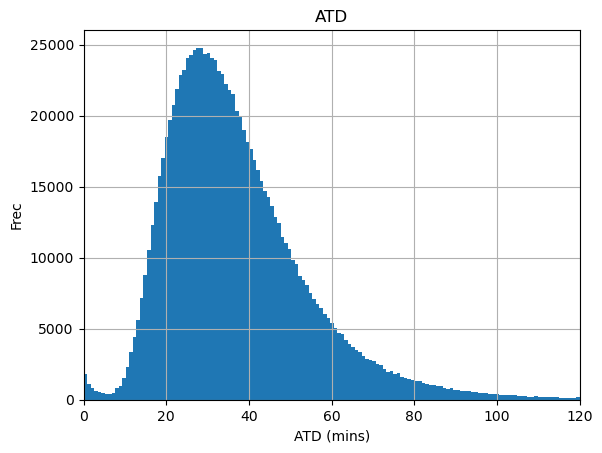

<Axes: xlabel='ATD'>

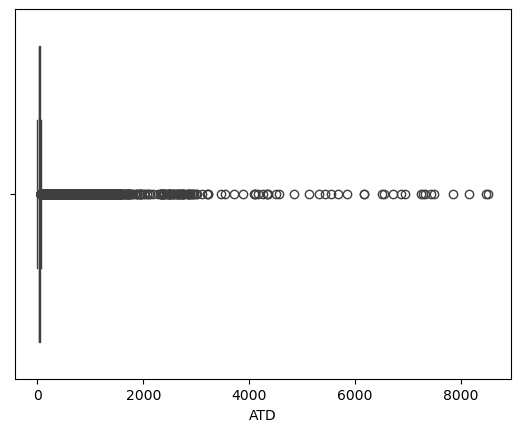

In [231]:
df['ATD'].hist(bins = 10000)
plt.title('ATD')
plt.xlabel('ATD (mins)')
plt.ylabel('Frec')
plt.xlim(0,120)
plt.show()

sns.boxplot(x=df['ATD'])

In [206]:
# Voy a probar con ATD_winsor
df['ATD_winsor'] = df['ATD'].clip(lower=df['ATD'].quantile(0.01), upper=df['ATD'].quantile(0.99))
df['ATD_winsor'].describe(percentiles=[.01, .25, .5, .75, .99])

count    1000000.000000
mean          37.564113
std           17.995692
min           10.216667
1%            10.216667
25%           25.116667
50%           33.933333
75%           45.683333
99%          112.233333
max          112.233333
Name: ATD_winsor, dtype: float64

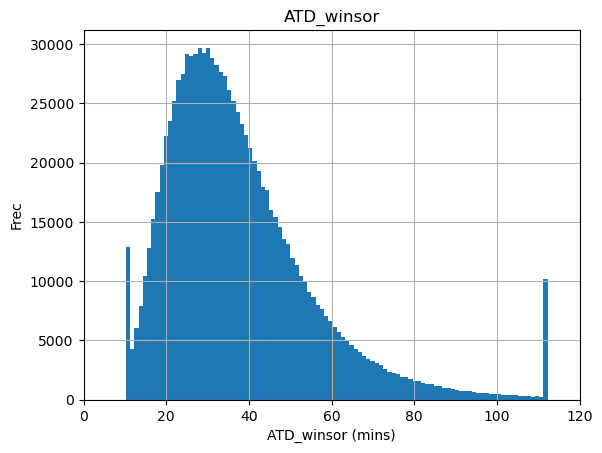

<Axes: xlabel='ATD_winsor'>

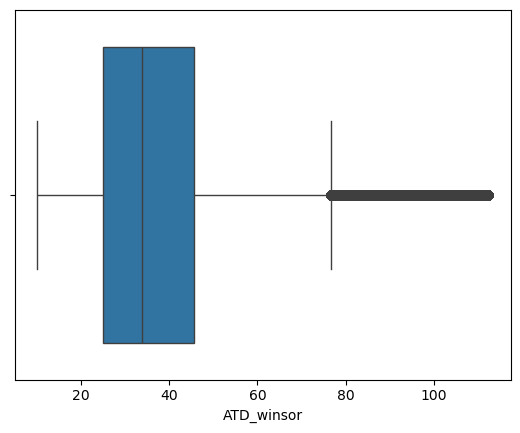

In [207]:
df['ATD_winsor'].hist(bins = 100)
plt.title('ATD_winsor')
plt.xlabel('ATD_winsor (mins)')
plt.ylabel('Frec')
plt.xlim(0,120)
plt.show()

sns.boxplot(x=df['ATD_winsor'])

In [ ]:
df['ATD'].hist(bins = 100)
plt.title('ATD')
plt.xlabel('ATD (mins)')
plt.ylabel('Frec')
plt.xlim(0,120)
plt.show()

sns.boxplot(x=df['ATD'])

Log(ATD + 1) se ve mejor:

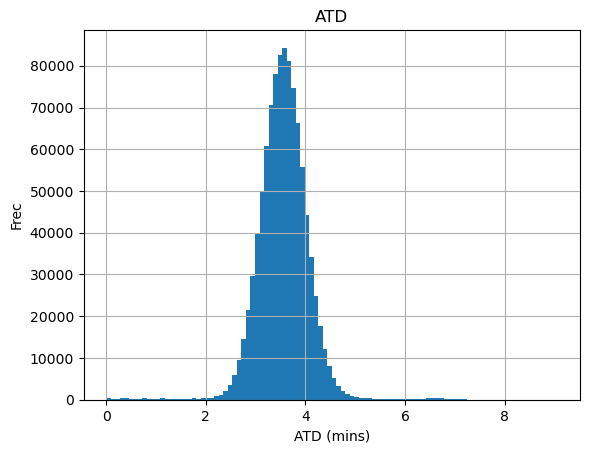

In [35]:
np.log1p(df['ATD']).hist(bins = 100)
plt.title('ATD')
plt.xlabel('ATD (mins)')
plt.ylabel('Frec')
#plt.xlim(0,120)
plt.show()

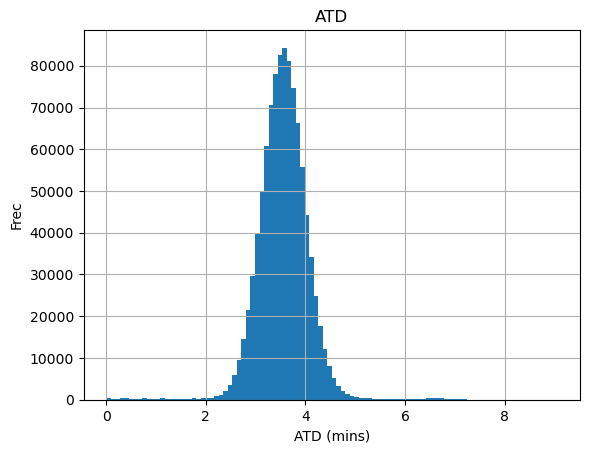

In [ ]:
np.log1p(df['ATD']).hist(bins = 100)
plt.title('ATD')
plt.xlabel('ATD (mins)')
plt.ylabel('Frec')
#plt.xlim(0,120)
plt.show()

# Comportamientos temporales

Vistazo a si hay algún patrón en la hora del día o día de la semana

to-do: convertir de UTC a tiempo local 

- Promedio de ATD a distintas horas del día
- Número de ordenes a distintas horas del día

Las órdenes toman más tiempo (ATD) en mientras más temprano se hacen (probablemente hay un menor número de conductores disponibles? -> Para testear se me ocurre que la distancia del pickup debe de ser mayor en esas horas)

Conforme avanza el día, aumenta el número de ordenes (count agrupando por hora) bajando el tiempo de entrega.

In [58]:
mexico_timezones = [tz for tz in pytz.all_timezones if 'Mexico' in tz]
print(mexico_timezones)

['America/Mexico_City', 'Mexico/BajaNorte', 'Mexico/BajaSur', 'Mexico/General']


In [ ]:
df['restaurant_offered_timestamp_local'] = df['restaurant_offered_timestamp_utc'].dt.tz_localize('UTC').dt.tz_convert('America/Mexico_City')


Text(0, 0.5, 'ATD promedio')

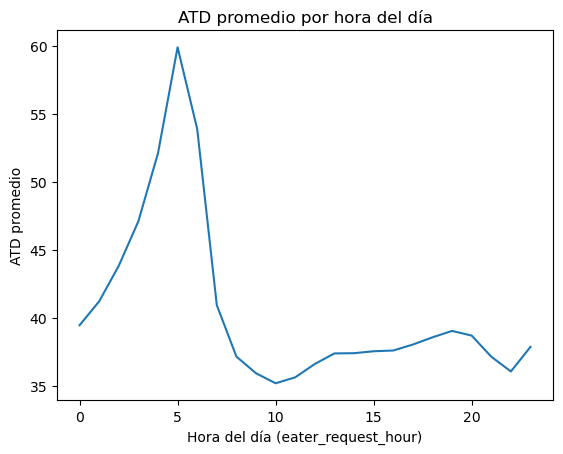

In [67]:
df['eater_request_hour'] = df['eater_request_timestamp_local'].dt.hour
df.groupby('eater_request_hour')['ATD'].mean().plot()
plt.title('ATD promedio por hora del día')
plt.xlabel('Hora del día (eater_request_hour)')
plt.ylabel('ATD promedio')

Text(0, 0.5, 'Número de órdenes')

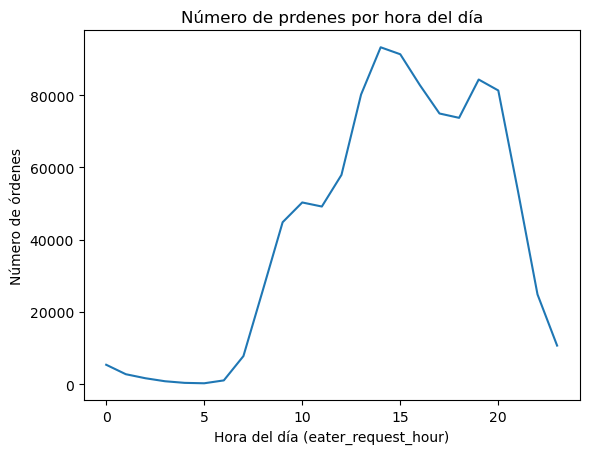

In [68]:
df.groupby('eater_request_hour').size().plot()
plt.title('Número de prdenes por hora del día')
plt.xlabel('Hora del día (eater_request_hour)')
plt.ylabel('Número de órdenes')

Debajo, vemos que como era de esperarse, el pickup distance es mayor en horas tempranas de la mañana y menor en la tarde (probablemente es un buen indicador de disponibilidad de usuarios -> aumenta el numero de ordenes, bajando el ATD y distancia)

El dropoff se comporta similar.

Text(0, 0.5, 'Distancia de pickup (km)')

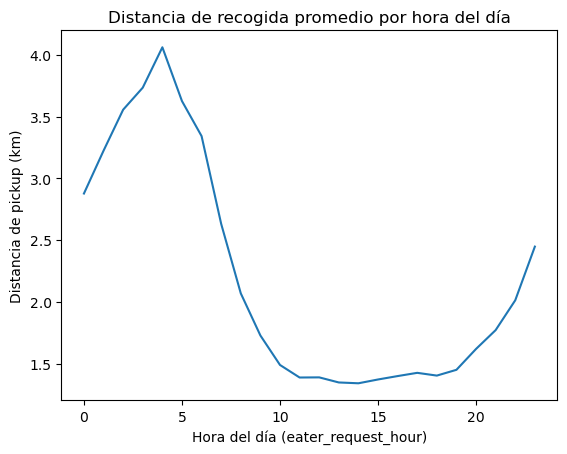

In [70]:
df.groupby('eater_request_hour')['pickup_distance'].mean().plot()
plt.title('Distancia de recogida promedio por hora del día')
plt.xlabel('Hora del día (eater_request_hour)')
plt.ylabel('Distancia de pickup (km)')

Text(0, 0.5, 'Distancia de entrega (km)')

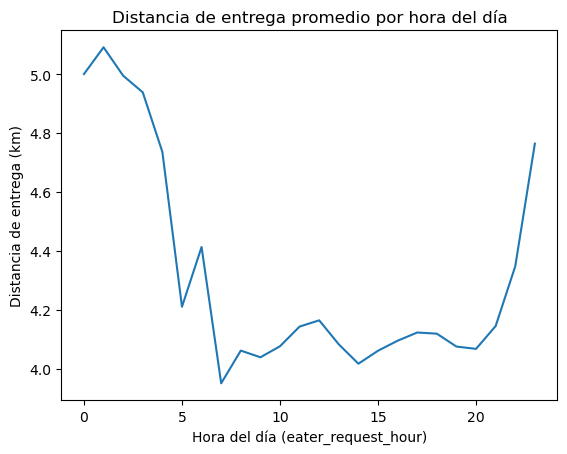

In [71]:
df.groupby('eater_request_hour')['dropoff_distance'].mean().plot()
plt.title('Distancia de entrega promedio por hora del día')
plt.xlabel('Hora del día (eater_request_hour)')
plt.ylabel('Distancia de entrega (km)')

Ahora hago lo mismo pero por día de la semana

Text(0, 0.5, 'ATD promedio')

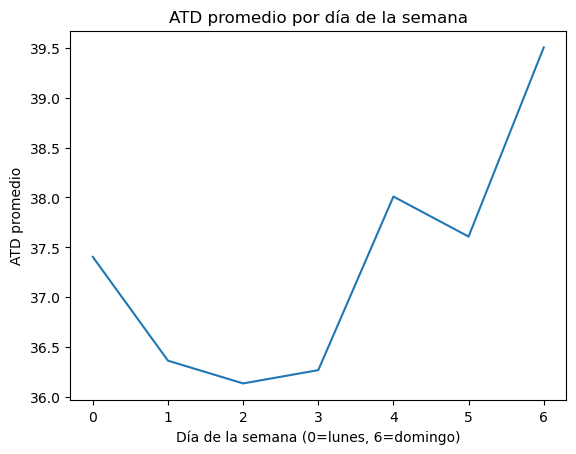

In [75]:
df['weekday'] = df['eater_request_timestamp_local'].dt.dayofweek
df.groupby('weekday')['ATD'].mean().plot()
plt.title('ATD promedio por día de la semana')
plt.xlabel('Día de la semana (0=lunes, 6=domingo)')
plt.ylabel('ATD promedio')


Text(0, 0.5, 'Número de órdenes')

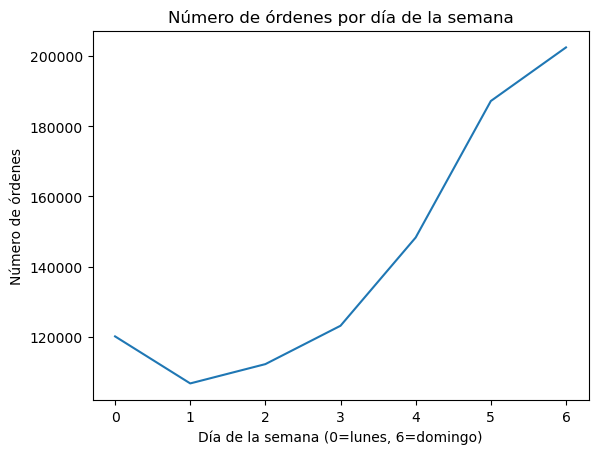

In [77]:
df.groupby('weekday').size().plot()
plt.title('Número de órdenes por día de la semana')
plt.xlabel('Día de la semana (0=lunes, 6=domingo)')
plt.ylabel('Número de órdenes')

Text(0, 0.5, 'Distancia de entrega (km)')

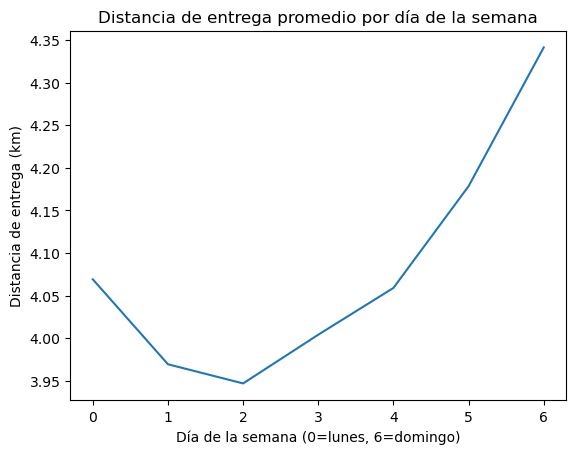

In [78]:
df.groupby('weekday')['dropoff_distance'].mean().plot()
plt.title('Distancia de entrega promedio por día de la semana')
plt.xlabel('Día de la semana (0=lunes, 6=domingo)')
plt.ylabel('Distancia de entrega (km)')

Text(0, 0.5, 'Distancia de recogida (km)')

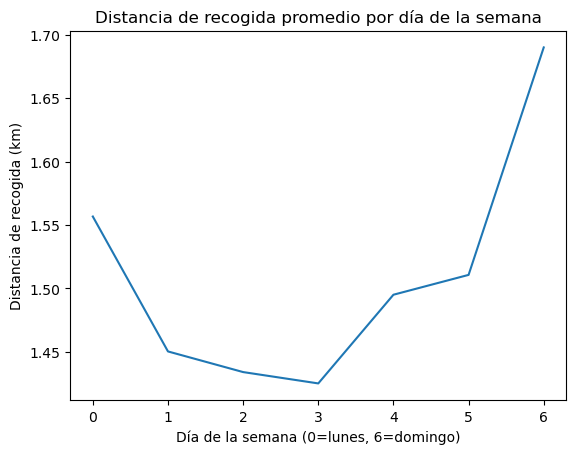

In [79]:
df.groupby('weekday')['pickup_distance'].mean().plot()
plt.title('Distancia de recogida promedio por día de la semana')
plt.xlabel('Día de la semana (0=lunes, 6=domingo)')
plt.ylabel('Distancia de recogida (km)')

In [96]:
df['date'] = df['eater_request_timestamp_local'].dt.date
df['date'] = pd.to_datetime(df['date'])
df['date'].min(), df['date'].max()

(Timestamp('2025-03-01 00:00:00'), Timestamp('2025-04-28 00:00:00'))

Solo tenemos datos de principio demarzo a finales de abril

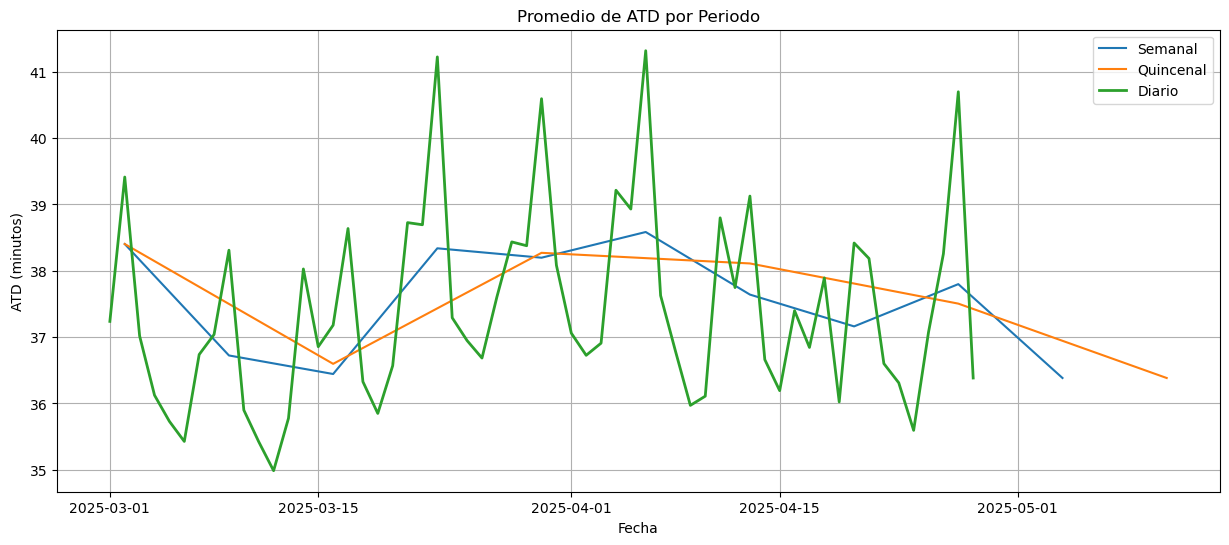

In [103]:
# asumiendo que fuera de algunos datos que estpen mal, la fecha es la misma que la hora de la solicitud del cliente
daily_atd = df.set_index('date').resample('D')['ATD'].mean()
weekly_atd = df.set_index('date').resample('W')['ATD'].mean()
biweekly_atd = df.set_index('date').resample('2W')['ATD'].mean()

plt.figure(figsize=(15, 6))
plt.plot(weekly_atd, label='Semanal')
plt.plot(biweekly_atd, label='Quincenal')
plt.plot(daily_atd, label='Diario', linewidth=2)

plt.title('Promedio de ATD por Periodo')
plt.xlabel('Fecha')
plt.ylabel('ATD (minutos)')
plt.legend()
plt.grid(True)
plt.show()

No hay suficiente data para un análisis semanal ni quincenal, pero sin duda se ve prometedor y sería algo a tener en cuenta

Graficando el daily atd lo que se ve es:
- una tendencia de aumento hacia los últimos días de marzo que que vamos a descartar porque es muy poca data para meterse con temas mensuales/quincenales
- una clara estacionalidad (ver seasnal debajo) diaria que confirma con mayor rigor estadístico lo expuesto en los gráficos anteriores, cada 7 días hay un pico durante el fin de semana
- El error mueestra evidencia favorable sobre que no hay una correlación aparente con ningún factor exógeno ni con la variable (ni una estructura) -> esto es buena señal a la hora de modelar

**Dejo el param periodo** porque por limpieza no dejé todos los periodos que probé, pero no por eso son menos interesantes y podrían probarse. Las conclusiones
ahi son que ningun otro periodo más allá del 7 es útil para modelar. Igualmente, probabndo con la decomposición multiplicativa, el residual fue siempre 1, clara alerta
de que con eso no podemos modelar.

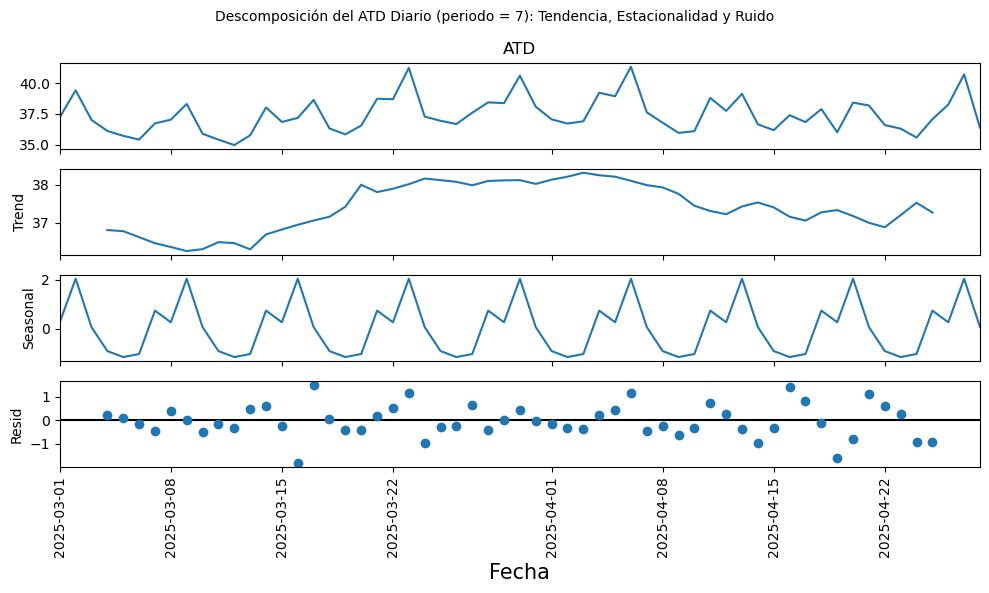

In [147]:
periodo = 7
decomposition = seasonal_decompose(daily_atd.dropna(), model='additive', period=periodo)
fig = decomposition.plot()
fig.set_size_inches(10, 6)
plt.suptitle(f'Descomposición del ATD Diario (periodo = {periodo}): Tendencia, Estacionalidad y Ruido', fontsize=10)
plt.xlabel('Fecha', fontsize=15)
plt.xticks(rotation=90, fontsize = 10)
plt.tight_layout()
plt.show()

In [156]:
df['is_weekend'] = df['weekday'].isin([5, 6])
df.groupby('is_weekend')['ATD'].aggregate(['size','mean', 'std']).reset_index()

,is_weekend,size,mean,std
0,False,610266,36.907098,17.941105
1,True,389734,38.592902,18.032835


$H_0 :=$ el ATD promedio entre fines de semana y días entre semana es igual

$H_1 :=$ el ATD promedio entre fines de semana y días entre semana es distinto


In [158]:
weekend_atd = df[df['is_weekend'] == True]['ATD'].dropna()
weekday_atd = df[df['is_weekend'] == False]['ATD'].dropna()

# correre una de Wlech porque no se cumple el supuesto de varianzas iguales
t_stat, p_value = ttest_ind(weekend_atd, weekday_atd, equal_var=False)

print(t_stat, p_value)

45.682225869458385 0.0


Esto es de gran utilidad saberlo para decisiones del negocio porque:
- Se pueden pre-asignar más couriers / mejore incentivos durante los fines de semana
- Se puede descomponer aún más a nivel zona y en zonas de gran demanda durante esos picos tener otra estrategia
- Si nos vamos más arriba, la hora del día también tiene un impacto importante de negocio -> ej: se pueden mejorar los incentivos en horarios donde hay evidencia a favor de agregar más couriers

En modelado:
- Tenemos evidencia para creer que la estacionalidad semanal es un buen predictor de ATD
- Tenemos evidencia para postular la creación de un forecast a largo plazo
- Tenemos evidencia para rechazar la hipótesis nula -> week_day podría ser un buen predictor del ATD

# Regional 
- Aquí lo lógico sería teniendo más entidades que la CDMX y mayor granularidad a nivel zona, hacer un choropleth interactivo
- Lo voy a implementar como parte del streamlit, por ahora quiero estudiar comportamientos a nivel zona

In [80]:
df.groupby('region')['ATD'].mean().sort_values(ascending=False)

/var/folders/mk/_ghzwf3j0hvf_yvj29dkl4lh0000gn/T/ipykernel_21245/898333091.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('region')['ATD'].mean().sort_values(ascending=False)


region
Mexico    37.564113
Name: ATD, dtype: float64

/var/folders/mk/_ghzwf3j0hvf_yvj29dkl4lh0000gn/T/ipykernel_21245/72184409.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('territory')['ATD'].mean().sort_values(ascending=False).reset_index())


,territory,ATD
0,Central,38.252149
1,North,37.932150
2,South East,37.890212
3,West,36.161852
4,Long Tail - Region,35.220570


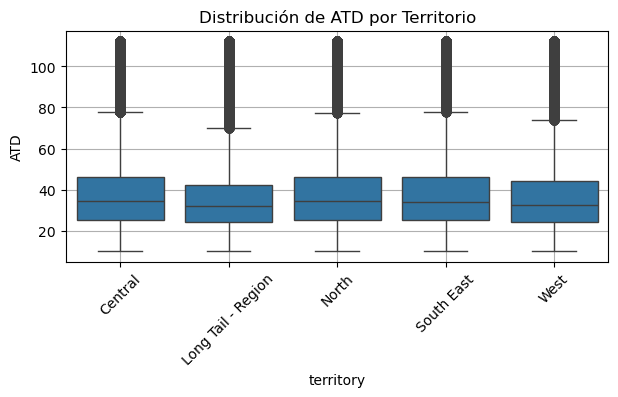

In [211]:
display(df.groupby('territory')['ATD'].mean().sort_values(ascending=False).reset_index())


plt.figure(figsize=(7, 3))
sns.boxplot(data=df, x='territory', y='ATD')
plt.title('Distribución de ATD por Territorio')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Atd es una variable con muchos outliers y un sesgo en su distribucipon claro, quizá media, mediana, boxplot no son la mejor forma de analizarla, pero nos va dando ideas de que hacer y una transformación con log por ejemplo nos quitaría interpretabilidad.

In [170]:
df.groupby(['territory', 'geo_archetype'])['ATD'].aggregate(['mean','std','size']).reset_index().sort_values(by = ['territory', 'mean'],
                                                                                    ascending=[True, False])

/var/folders/mk/_ghzwf3j0hvf_yvj29dkl4lh0000gn/T/ipykernel_21245/2695070586.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['territory', 'geo_archetype'])['ATD'].aggregate(['mean','std','size']).reset_index().sort_values(by = ['territory', 'mean'],


,territory,geo_archetype,mean,std,size
4,Central,Unlaunched,39.314803,17.108777,483
3,Central,Play offense,38.723235,18.270430,47387
1,Central,Defend CP,38.673310,19.412811,206551
5,Central,Unspecified,38.541878,17.673706,8009
2,Central,Drive momentum,37.386547,17.820694,82375
0,Central,Build experience,36.942826,17.086986,31195
8,Long Tail - Region,Drive momentum,35.777487,15.899703,51485
6,Long Tail - Region,Build experience,33.535840,15.551113,13548
11,Long Tail - Region,Unspecified,33.320598,16.545209,3078
7,Long Tail - Region,Defend CP,NaN,NaN,0


Una constante clara, mucha varianza en nuestros datos, eso puede ser interesante. Sin embargo, vemos que una distinción extra dentro de territorio para estudiar los arquetipos, puede ser util

/var/folders/mk/_ghzwf3j0hvf_yvj29dkl4lh0000gn/T/ipykernel_21245/1729418821.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.boxplot(data=df, x='geo_archetype', y='ATD', order=df.groupby('geo_archetype')['ATD'].mean().sort_values(ascending=False).index) # no es optimo pero asi no ando guardando los valores


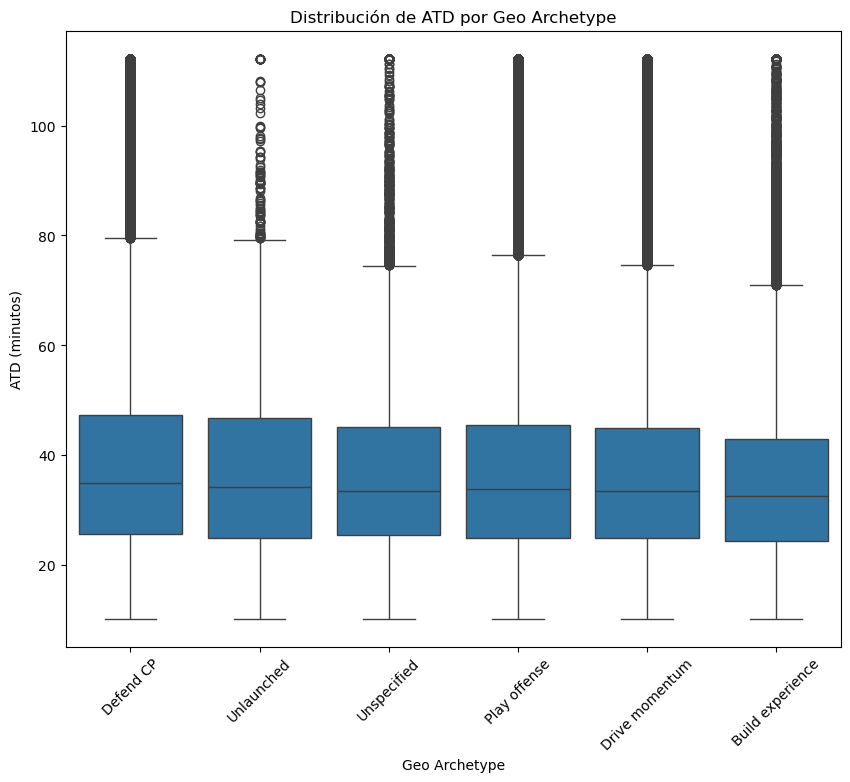

In [198]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=df, x='geo_archetype', y='ATD', order=df.groupby('geo_archetype')['ATD'].mean().sort_values(ascending=False).index) # no es optimo pero asi no ando guardando los valores
plt.xlabel('Geo Archetype')
plt.ylabel('ATD (minutos)')
plt.title('Distribución de ATD por Geo Archetype')
plt.xticks(rotation=45) 
plt.show()

# Courier y flujo

No me termina de hacer sentido la presencia de couriers tan especificos como Logistica y Fleet. Sin embargo, el boxplot debajo permite ver que el tipo de courier es predictor potencialmente bueno.

to-do : esperar a resuesta de sofi/moni 

/var/folders/mk/_ghzwf3j0hvf_yvj29dkl4lh0000gn/T/ipykernel_21245/134068927.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.boxplot(data=df, x='courier_flow', y='ATD', order=df.groupby('courier_flow')['ATD'].mean().sort_values(ascending=False).index) # no es optimo pero asi no ando guardando los valores


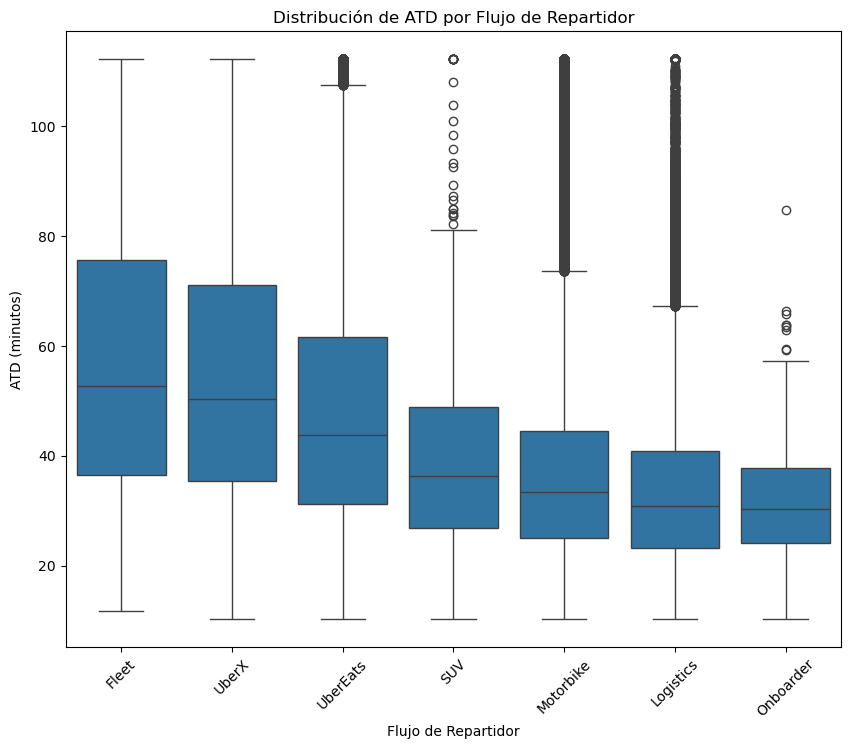

In [210]:
# boxplot for courier flow mean atd 
# sort the values by mean ATD and plot the boxplot as below
plt.figure(figsize=(10, 8))
sns.boxplot(data=df, x='courier_flow', y='ATD', order=df.groupby('courier_flow')['ATD'].mean().sort_values(ascending=False).index) # no es optimo pero asi no ando guardando los valores
plt.xlabel('Flujo de Repartidor')
plt.ylabel('ATD (minutos)')
plt.title('Distribución de ATD por Flujo de Repartidor')
plt.xticks(rotation=45) 
plt.show()


Aunque hay muchísima variabilidad, es interesante ver si el tipo de courier por zona muestra comportamientos interesantes
esto podría definir una estrategia del deployment de couriers específicos segpun el arquetipo de la zona.

In [197]:
df.groupby(['courier_flow','geo_archetype'])['ATD'].aggregate(['mean','std','size']).reset_index().sort_values(by = ['courier_flow', 'mean'],
                                                                                    ascending=[True, False])

/var/folders/mk/_ghzwf3j0hvf_yvj29dkl4lh0000gn/T/ipykernel_21245/2960333937.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['courier_flow','geo_archetype'])['ATD'].aggregate(['mean','std','size']).reset_index().sort_values(by = ['courier_flow', 'mean'],


,courier_flow,geo_archetype,mean,std,size
4,Fleet,Unlaunched,112.233333,NaN,1
0,Fleet,Build experience,64.654207,28.557192,103
2,Fleet,Drive momentum,59.398240,27.320787,483
3,Fleet,Play offense,58.665208,27.768001,560
5,Fleet,Unspecified,55.857692,22.762562,13
1,Fleet,Defend CP,52.754612,24.748315,206
11,Logistics,Unspecified,39.345688,17.278564,143
8,Logistics,Drive momentum,34.391004,15.771696,16365
9,Logistics,Play offense,33.861806,15.977636,16821
7,Logistics,Defend CP,33.780973,15.487568,26889
